In [8]:
import os
import sys

import numpy as np
from scipy.integrate import trapezoid
from scipy.interpolate import RegularGridInterpolator as rgi
from scipy.interpolate import interp1d
from tqdm import tqdm

# Add src to path for imports
# Jupyter notebooks do not define __file__, so use the current working directory
sys.path.append(os.path.join(r"C:\Users\Carlos\CursorProjects\FLARE-BB", "src"))
# Change the working directory to the root of the project
os.chdir(r"C:\Users\Carlos\CursorProjects\FLARE-BB")

from data_processing.kde_generator import load_kde_data_with_metadata
from data_processing.kde_utils import find_kde_by_parameters, list_kde_files


def load_kde_data(kde_dir: str = None, target_params: dict = None) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Load KDE data from HDF5 files following repository standards.

    :param kde_dir: Directory containing KDE files (default: data/cache/kde)
    :type kde_dir: str, optional
    :param target_params: Specific parameters to match for file selection
    :type target_params: dict, optional
    :returns: Tuple of (kde_data, points, values, metadata)
    :rtype: tuple[np.ndarray, np.ndarray, np.ndarray, dict]
    :raises FileNotFoundError: If no suitable KDE file is found
    """
    if kde_dir is None:
        kde_dir = os.path.join("data", "cache", "kde")

    if not os.path.exists(kde_dir):
        raise FileNotFoundError(f"KDE directory not found: {kde_dir}")

    # If specific parameters are provided, try to find matching file
    if target_params:
        filepath = find_kde_by_parameters(target_params, kde_dir)
        if filepath:
            print(f"Found KDE file matching parameters: {os.path.basename(filepath)}")
        else:
            raise FileNotFoundError(f"No KDE file found matching parameters: {target_params}")
    else:
        # Otherwise, find any available KDE file
        kde_files = list_kde_files(kde_dir)
        if not kde_files:
            raise FileNotFoundError(f"No KDE files found in {kde_dir}")

        # Use the first available file
        filepath = kde_files[0]
        print(f"Using KDE file: {os.path.basename(filepath)}")

    # Load the data using the repository's standard function
    kde_data, points, values, metadata = load_kde_data_with_metadata(filepath)

    # Display metadata information
    print("KDE File Metadata:")
    print(f"  • Generation timestamp: {metadata.get('generation_timestamp', 'N/A')}")
    print(f"  • File format version: {metadata.get('file_format_version', 'N/A')}")

    if "kde_parameters" in metadata:
        params = metadata["kde_parameters"]
        print(f"  • Grid size: {params.get('nbins', 'N/A')}x{params.get('nbins', 'N/A')}")
        print(f"  • Bandwidth: {params.get('bandwidth', 'N/A')}")
        print(f"  • TS threshold: {params.get('ts_threshold', 'N/A')}")
        print(f"  • X range: [{params.get('x_low', 'N/A')}, {params.get('x_high', 'N/A')}]")
        print(f"  • Y range: [{params.get('y_low', 'N/A')}, {params.get('y_high', 'N/A')}]")

    return kde_data, points, values, metadata

In [9]:
kde_data, points, values, metadata = load_kde_data()

Using KDE file: kde_bw0.2_n512_ts19_flux-energy_x-4.9to-2.8_y-5.35to-3.25.h5
KDE File Metadata:
  • Generation timestamp: 2025-07-23T17:26:33.826211
  • File format version: 1.0
  • Grid size: 512x512
  • Bandwidth: 0.2
  • TS threshold: 19
  • X range: [-4.9, -2.8]
  • Y range: [-5.35, -3.25]


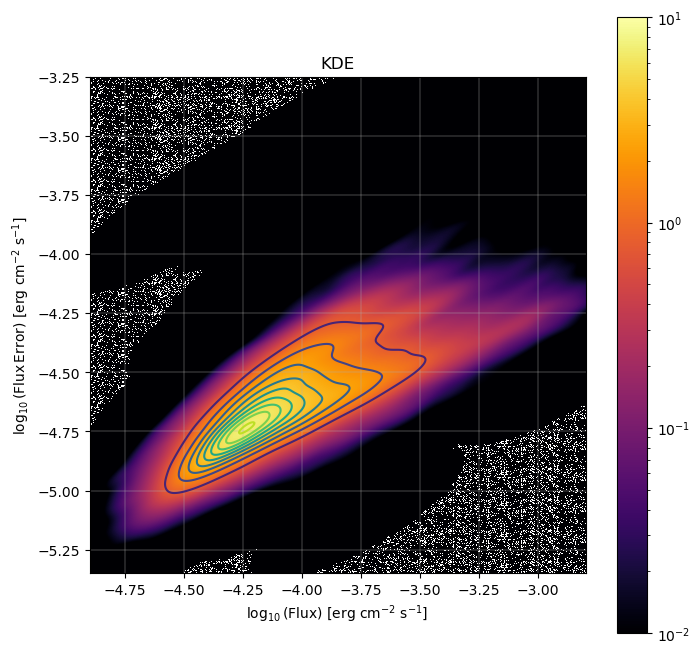

In [16]:
# Plot the KDE data
import matplotlib.pyplot as plt
from matplotlib import colors

nbins = metadata["kde_parameters"]["nbins"]
x_low = metadata["kde_parameters"]["x_low"]
x_high = metadata["kde_parameters"]["x_high"]
y_low = metadata["kde_parameters"]["y_low"]
y_high = metadata["kde_parameters"]["y_high"]

zi = np.exp(values)
xi = points[:, 0].reshape(nbins, nbins)
yi = points[:, 1].reshape(nbins, nbins)

# Plot using imshow
fig, ax = plt.subplots(figsize=(8, 8))
pos = ax.imshow(
    zi.reshape(xi.shape).T,
    origin="lower",
    aspect="auto",
    extent=[x_low, x_high, y_low, y_high],
    cmap="inferno",
    norm=colors.LogNorm(vmin=1e-2, vmax=1e1),
)
# Add a colorbar
plt.colorbar(pos, ax=ax)
# Also plot contours
ax.contour(xi, yi, zi.reshape(xi.shape), levels=10, cmap="viridis", zorder=5)
# plt.colorbar(plt.cm.ScalarMappable(norm=colors.LogNorm(vmin=zi.min(), vmax=zi.max()), cmap="inferno"), ax=ax)
# Set limits
ax.set_xlim([x_low, x_high])
ax.set_ylim([y_low, y_high])
# Set aspect ratio to be equal
ax.set_aspect("equal", adjustable="box")
# Add a thick grid
ax.grid(which="both", linestyle="-", linewidth=0.3, zorder=10)
# Set labels
ax.set_xlabel(r"$\log_{10}(\mathrm{Flux})$ [erg cm$^{-2}$ s$^{-1}$]")
ax.set_ylabel(r"$\log_{10}(\mathrm{Flux\,Error})$ [erg cm$^{-2}$ s$^{-1}$]")
# Set title
plt.title("KDE")
plt.show()

In [21]:
"""Main function to build flux distributions from KDE data."""
print("🔬 Building Flux Distributions from KDE Data")
print("=" * 60)

print("Loading KDE data...")
try:
    # You can specify target parameters if needed, for example:
    # target_params = {
    #     'bandwidth': 0.2,
    #     'nbins': 512,
    #     'ts_threshold': 19,
    #     'flux_type': 'energy'
    # }
    # kde_data, points, values, metadata = load_kde_data(target_params=target_params)

    # For now, load any available KDE file
    kde_data, points, values, metadata = load_kde_data()

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("💡 Run 'python scripts/generate_kde.py' first to generate KDE data.")

# Extract grid information from the data
resolution = int(np.sqrt(points.shape[0]))
x_low, x_high = points[:, 0].min(), points[:, 0].max()
y_low, y_high = points[:, 1].min(), points[:, 1].max()

print(
    f"KDE grid: {resolution}x{resolution}, x_range: [{x_low:.3f}, {x_high:.3f}], y_range: [{y_low:.3f}, {y_high:.3f}]"
)

# Normalize the KDE
xs = points[:, 0].reshape((resolution, resolution)).T[0, :]
ys = points[:, 1].reshape((resolution, resolution))[0, :]
ps = np.exp(values).reshape((resolution, resolution)).T
total = trapezoid(trapezoid(ps, xs), ys)
s_values = values - np.log(total)

# Make a linear interpolation of the KDE
xi = points[:, 0].reshape((resolution, resolution))
yi = points[:, 1].reshape((resolution, resolution))
k_spline = rgi((xi[:, 0], yi[0, :]), s_values.reshape(resolution, resolution), method="linear")

# Evaluate a HD grid for normalization
hd_res = 1024
xi_hd, yi_hd = np.mgrid[x_low : x_high : hd_res * 1j, y_low : y_high : hd_res * 1j]
zi_hd = np.exp(k_spline((xi_hd.flatten(), yi_hd.flatten())).reshape(xi_hd.shape))
norm_hd = trapezoid(trapezoid(zi_hd, xi_hd[:, 0]), yi_hd[0, :])


# Define a pdf function
def pdf(x, y):
    return np.exp(k_spline((x, y))) / norm_hd


print("Defining conditional PDF...")


# Conditional pdf function
def cond_pdf(fr, fm, sm):
    _flux = 10**fm
    _error = 10**sm
    _sigma = np.log(_flux + _error) - np.log(_flux)
    _mu = np.log(_flux) - 0.5 * _sigma**2
    _measured_flux = 10**fr
    return (
        1
        / (_measured_flux * _sigma * np.sqrt(2 * np.pi))
        * np.exp(-((np.log(_measured_flux) - _mu) ** 2) / (2 * _sigma**2))
    )


print("Calculating prior distribution (this may take several minutes)...")


# Prior calculation
def prior(fr, _res=128):
    integrand = lambda fm, sm: cond_pdf(fr, fm, sm) * pdf(fm, sm) * 10**fr * np.log(10)
    # Do a meshgrid
    x, y = np.mgrid[x_low : x_high : _res * 1j, y_low : y_high : _res * 1j]
    # Evaluate the integrand
    z = integrand(x, y)
    return trapezoid(trapezoid(z, x[:, 0]), y[0, :])


# Vectorize the prior
prior = np.vectorize(prior)

# Calculate prior values
xx_prior = np.linspace(x_low - 3, x_high + 3, 500)
yy_prior = prior(xx_prior, _res=hd_res)

# Create interpolation for prior
prior_values = np.log(yy_prior)  # Save the log of the prior for better accuracy
k_spline2 = interp1d(xx_prior, prior_values, kind="linear")


def pfr(fr):
    return np.exp(k_spline2(fr))


# Vectorize the prior
pfr = np.vectorize(pfr)

print("Defining final PDF...")
# Conditional pdf in log space
logs_cond_pdf = lambda fr, fm, sm: cond_pdf(fr, fm, sm) * 10**fr * np.log(10)
logs_cond_pdf = np.vectorize(logs_cond_pdf)


# Final PDF function
def final_pdf(fr, fm, sm):
    return logs_cond_pdf(fr, fm, sm) * pdf(fm, sm) / pfr(fr)


final_pdf = np.vectorize(final_pdf)

print("Generating flux PDFs...")
# Generate flux PDFs for different real flux values
r_flux_range = np.linspace(-4.75, -3, 256)
nbins = 256
xx, yy = np.mgrid[x_low : x_high : nbins * 1j, y_low : y_high : nbins * 1j]

zzs = []
for real_flux in tqdm(r_flux_range, desc="Computing flux PDFs"):
    zz = final_pdf(real_flux, xx.flatten(), yy.flatten()).reshape(xx.shape)
    zzs.append(zz)

# Convert to numpy array
zzs = np.array(zzs)

print("Creating 3D meshgrid...")
# Create the 3D meshgrid
xs = np.linspace(x_low, x_high, nbins)
ys = np.linspace(y_low, y_high, nbins)
frs = np.linspace(-4.75, -3, nbins)
xx, yy, ff = np.meshgrid(xs, ys, frs, indexing="ij")

# Process valz
valz = np.log(zzs + 1e-300)
# Reorder the axis of valz, such that 0:1:2 -> 2:1:0
valz = np.moveaxis(valz, 0, 2)

# Let's verify if the data matches the true one at C:\Users\Carlos\PycharmProjects\IceCubeResearch\blazar_research\jax_arrays.npz
existing_data = np.load("C:/Users/Carlos/PycharmProjects/IceCubeResearch/blazar_research/jax_arrays.npz")
existing_xx = existing_data["xx"]
existing_yy = existing_data["yy"]
existing_ff = existing_data["ff"]
existing_valz = existing_data["valz"]

# Compare shapes
print("Shape comparison:")
print(f"  xx: generated={xx.shape}, existing={existing_xx.shape}, match={xx.shape == existing_xx.shape}")
print(f"  yy: generated={yy.shape}, existing={existing_yy.shape}, match={yy.shape == existing_yy.shape}")
print(f"  ff: generated={ff.shape}, existing={existing_ff.shape}, match={ff.shape == existing_ff.shape}")
print(f"  valz: generated={valz.shape}, existing={existing_valz.shape}, match={valz.shape == existing_valz.shape}")

# Compare values
if xx.shape == existing_xx.shape:
    xx_diff = np.abs(xx - existing_xx)
    print(f"  xx max absolute difference: {np.max(xx_diff):.2e}")
    print(f"  xx mean absolute difference: {np.mean(xx_diff):.2e}")
    print(f"  xx all close (rtol=1e-10): {np.allclose(xx, existing_xx, rtol=1e-10)}")

if yy.shape == existing_yy.shape:
    yy_diff = np.abs(yy - existing_yy)
    print(f"  yy max absolute difference: {np.max(yy_diff):.2e}")
    print(f"  yy mean absolute difference: {np.mean(yy_diff):.2e}")
    print(f"  yy all close (rtol=1e-10): {np.allclose(yy, existing_yy, rtol=1e-10)}")

if ff.shape == existing_ff.shape:
    ff_diff = np.abs(ff - existing_ff)
    print(f"  ff max absolute difference: {np.max(ff_diff):.2e}")
    print(f"  ff mean absolute difference: {np.mean(ff_diff):.2e}")
    print(f"  ff all close (rtol=1e-10): {np.allclose(ff, existing_ff, rtol=1e-10)}")

if valz.shape == existing_valz.shape:
    valz_diff = np.abs(valz - existing_valz)
    print(f"  valz max absolute difference: {np.max(valz_diff):.2e}")
    print(f"  valz mean absolute difference: {np.mean(valz_diff):.2e}")
    print(f"  valz all close (rtol=1e-5): {np.allclose(valz, existing_valz, rtol=1e-5)}")
    print(f"  valz all close (rtol=1e-3): {np.allclose(valz, existing_valz, rtol=1e-3)}")

    # Check for NaN or inf values
    print(f"  valz has NaN: generated={np.any(np.isnan(valz))}, existing={np.any(np.isnan(existing_valz))}")
    print(f"  valz has Inf: generated={np.any(np.isinf(valz))}, existing={np.any(np.isinf(existing_valz))}")

    # Show some statistics
    print(
        f"  valz range: generated=[{np.min(valz):.3f}, {np.max(valz):.3f}], existing=[{np.min(existing_valz):.3f}, {np.max(existing_valz):.3f}]"
    )

print("\nComparison complete!")

print("Saving JAX arrays...")

# TODO: Add proper saving logic here
print("✅ Distribution building complete!")
print("💡 Next: Implement proper output saving following repository standards")

🔬 Building Flux Distributions from KDE Data
Loading KDE data...
Using KDE file: kde_bw0.2_n512_ts19_flux-energy_x-4.9to-2.8_y-5.35to-3.25.h5
KDE File Metadata:
  • Generation timestamp: 2025-07-23T17:26:33.826211
  • File format version: 1.0
  • Grid size: 512x512
  • Bandwidth: 0.2
  • TS threshold: 19
  • X range: [-4.9, -2.8]
  • Y range: [-5.35, -3.25]
KDE grid: 512x512, x_range: [-4.900, -2.800], y_range: [-5.350, -3.250]
Defining conditional PDF...
Calculating prior distribution (this may take several minutes)...
Defining final PDF...
Generating flux PDFs...


Computing flux PDFs: 100%|██████████| 256/256 [48:39<00:00, 11.40s/it]


Creating 3D meshgrid...
Shape comparison:
  xx: generated=(256, 256, 256), existing=(256, 256, 256), match=True
  yy: generated=(256, 256, 256), existing=(256, 256, 256), match=True
  ff: generated=(256, 256, 256), existing=(256, 256, 256), match=True
  valz: generated=(256, 256, 256), existing=(256, 256, 256), match=True
  xx max absolute difference: 0.00e+00
  xx mean absolute difference: 0.00e+00
  xx all close (rtol=1e-10): True
  yy max absolute difference: 0.00e+00
  yy mean absolute difference: 0.00e+00
  yy all close (rtol=1e-10): True
  ff max absolute difference: 0.00e+00
  ff mean absolute difference: 0.00e+00
  ff all close (rtol=1e-10): True
  valz max absolute difference: 2.76e+01
  valz mean absolute difference: 6.46e-01
  valz all close (rtol=1e-5): False
  valz all close (rtol=1e-3): False
  valz has NaN: generated=False, existing=False
  valz has Inf: generated=False, existing=False
  valz range: generated=[-690.776, 4.630], existing=[-690.776, 4.669]

Comparison comp

In [22]:
if valz.shape == existing_valz.shape:
    valz_diff = np.abs(np.exp(valz) - np.exp(existing_valz))
    print(f"  valz max absolute difference: {np.max(valz_diff):.2e}")
    print(f"  valz mean absolute difference: {np.mean(valz_diff):.2e}")
    print(f"  valz all close (rtol=1e-5): {np.allclose(valz, existing_valz, rtol=1e-5)}")
    print(f"  valz all close (rtol=1e-3): {np.allclose(valz, existing_valz, rtol=1e-3)}")

    # Check for NaN or inf values
    print(f"  valz has NaN: generated={np.any(np.isnan(valz))}, existing={np.any(np.isnan(existing_valz))}")
    print(f"  valz has Inf: generated={np.any(np.isinf(valz))}, existing={np.any(np.isinf(existing_valz))}")

    # Show some statistics
    print(
        f"  valz range: generated=[{np.min(valz):.3f}, {np.max(valz):.3f}], existing=[{np.min(existing_valz):.3f}, {np.max(existing_valz):.3f}]"
    )

  valz max absolute difference: 5.13e+00
  valz mean absolute difference: 5.31e-03
  valz all close (rtol=1e-5): False
  valz all close (rtol=1e-3): False
  valz has NaN: generated=False, existing=False
  valz has Inf: generated=False, existing=False
  valz range: generated=[-690.776, 4.630], existing=[-690.776, 4.669]


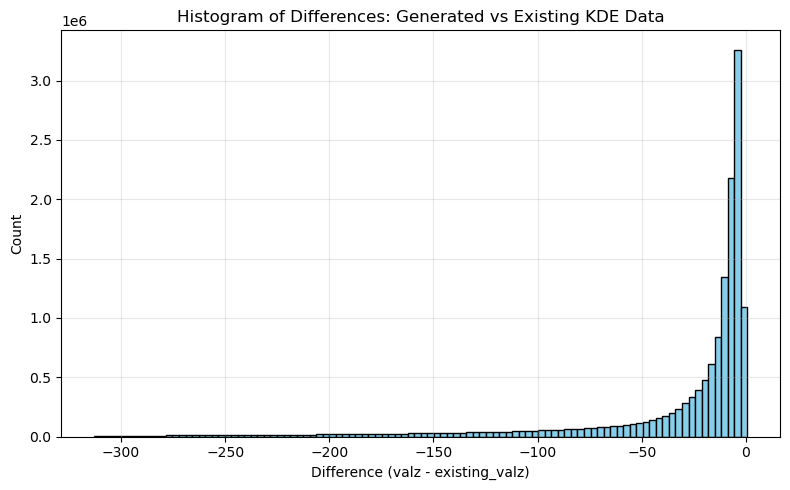

In [29]:
# Plot a histogram of the difference between the generated and existing KDE data
import matplotlib.pyplot as plt

# Compute the difference between the generated and existing KDE data
if valz.shape == existing_valz.shape:
    diff = np.log10(valz_diff[valz_diff > 0])
    plt.figure(figsize=(8, 5))
    plt.hist(diff.ravel(), bins=100, color="skyblue", edgecolor="k")
    plt.title("Histogram of Differences: Generated vs Existing KDE Data")
    plt.xlabel("Difference (valz - existing_valz)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Shapes do not match; cannot plot histogram of differences.")

In [31]:
# Count how many values difference are exactly 0
# Count how many values in valz_diff are exactly zero
if valz.shape == existing_valz.shape:
    num_exact_zeros = np.sum(valz_diff < 1e-10)
    total_elements = valz_diff.size
    print(
        f"Number of exactly zero differences: {num_exact_zeros} / {total_elements} ({num_exact_zeros / total_elements:.2%})"
    )
else:
    print("Shapes do not match; cannot count exact zero differences.")

Number of exactly zero differences: 9611844 / 16777216 (57.29%)


In [33]:
# Print the 90%, 95%, 99% and 99.9% quantiles of the difference between the generated and existing KDE data
# Print the 90%, 95%, 99%, and 99.9% quantiles of the difference between the generated and existing KDE data
if valz.shape == existing_valz.shape:
    quantiles = [0.9, 0.95, 0.99, 0.999]
    quantile_values = np.quantile(valz_diff, quantiles)
    for q, v in zip(quantiles, quantile_values):
        print(f"{q:.1%} quantile of difference: {v:.3e}")
else:
    print("Shapes do not match; cannot compute quantiles of differences.")

90.0% quantile of difference: 7.009e-04
95.0% quantile of difference: 8.815e-03
99.0% quantile of difference: 1.403e-01
99.9% quantile of difference: 5.555e-01
